<a href="https://colab.research.google.com/github/arsingla786/ImageProcessing/blob/main/IP_assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1. WAP to enhance the input image using Log transform. Assume c=1

In [ ]:
#log transform  ->
# s=clog(1+r)

# where:

# r = input pixel intensity
# s = output pixel intensity
# c=1 as given in the question

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("/content/_- visual selection (1).png", 0)


In [3]:
# Log transformation
c = 1
log_image = c * np.log(1 + img.astype(np.float32))

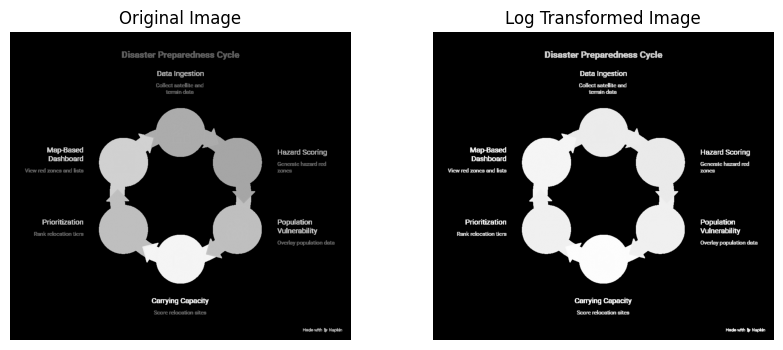

In [4]:
# Normalize to 0-255
log_image = cv2.normalize(
    log_image,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

log_image = log_image.astype(np.uint8)

# Display
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(log_image, cmap="gray")
plt.title("Log Transformed Image")
plt.axis("off")

plt.show()

In [ ]:
#2. WAP to enhance the input image using Power law/gamma transform. Assume c=1,
#   and input the value of gamma from the user

In [ ]:
# 2. Power Law / Gamma Transformation
# Formula
# s=cr^γ   c=1

Enter gamma value: 5


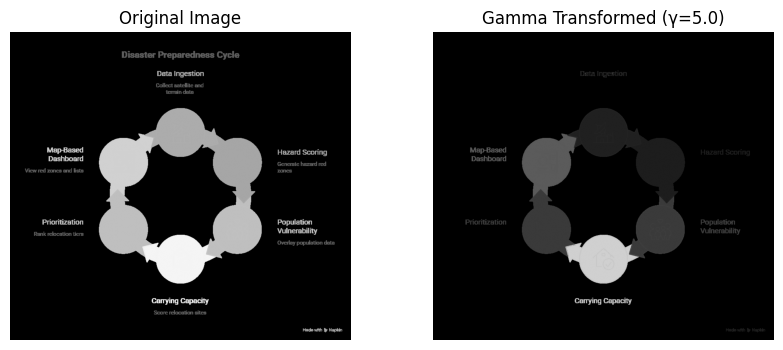

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("/content/_- visual selection (1).png", 0)

# Take gamma from user
gamma = float(input("Enter gamma value: "))

# Normalize pixel values from 0-255 to 0-1
normalized = img / 255.0

# Power law transformation
c = 1
gamma_image = c * np.power(normalized, gamma)

# Convert back to 0-255
gamma_image = np.uint8(gamma_image * 255)

# Display
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gamma_image, cmap="gray")
plt.title(f"Gamma Transformed (γ={gamma})")
plt.axis("off")

plt.show()

In [ ]:
# 3. WAP to enhance the input image using Intensity level slicing (Contrast stretching).
# The input range of intensity values and the desired range of intensity values in the
# output image are obtained from the user. (Example: The input range of intensity
# values from 80 to 120 is stretched to 50-150 in the output image)

Enter input lower limit: 2
Enter input upper limit: 2
Enter output lower limit: 2
Enter output upper limit: 2


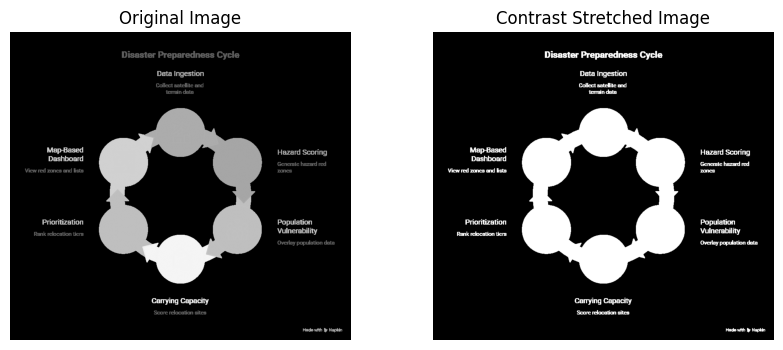

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("/content/_- visual selection (1).png", 0)

# Input range
r_min = int(input("Enter input lower limit: "))
r_max = int(input("Enter input upper limit: "))

# Output range
s_min = int(input("Enter output lower limit: "))
s_max = int(input("Enter output upper limit: "))

# Create output image
output = np.zeros_like(img, dtype=np.uint8)

# Pixels below input range
output[img < r_min] = 0

# Pixels above input range
output[img > r_max] = 255

# Pixels inside input range
mask = (img >= r_min) & (img <= r_max)

output[mask] = (
    s_min +
    ((img[mask] - r_min) * (s_max - s_min))
    / (r_max - r_min)
).astype(np.uint8)

# Display
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(output, cmap="gray")
plt.title("Contrast Stretched Image")
plt.axis("off")

plt.show()